# Price Mortality Theory

By: Jose Reyes

Date: 03/03/2026

### Overview

This script constructs a **data-driven volatility forecasting framework** built entirely from price data. Starting from raw log returns $r_t = \ln(P_t / P_{t-1})$, it estimates realized volatility $\hat{\sigma}_h(t)$ across multiple horizons, then builds a momentum surface $\mu(W, t)$ by differentiating the SMA field with respect to both window size $W$ and time $t$. The core question is whether $\mu(W, t)$ — a scale-invariant measure of how aggressively the trend is changing — carries **predictive signal** for future volatility. This is tested non-parametrically via Spearman rank correlation across the full $(W, h)$ grid, yielding a heatmap that reveals which trend-window and forecast-horizon combinations are most informative. The pipeline concludes by selecting the optimal pair $(W^*, h^*)$ that maximises $\rho_S$, providing a principled, data-driven basis for choosing a forecasting configuration.

## Environment Setup

### Install Dependencies

In [27]:
%cd /home/jose/signal-analysis
%pip install -r requirements.txt -q
%cd notebooks

/home/jose/signal-analysis


/home/jose/signal-analysis/venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Note: you may need to restart the kernel to use updated packages.
/home/jose/signal-analysis/notebooks


### Import Libraries

In [28]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import spearmanr

### Load Data

In [29]:
ticker = "AAPL"

df = yf.download(ticker, period="5y", interval="1d", auto_adjust=True)
df["Day"] = np.arange(len(df))
df["Log Returns"] = np.log(df["Close"] / df["Close"].shift(1))
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Day,Log Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2021-03-03,118.885887,122.440972,118.671607,121.564375,112966300,0,NaN
2021-03-04,117.006081,120.385846,115.535353,118.583956,178155000,1,-0.015938
2021-03-05,118.262550,118.769032,114.512669,117.833997,153766600,2,0.010681
2021-03-08,113.334137,117.853476,113.188036,117.785297,154376600,3,-0.042567
2021-03-09,117.941101,118.885878,115.700916,115.934673,129525800,4,0.039845


## Example of Realized Volatility by Horizon (RVH) and Price Mortality (PM)

### Realized Volatility by Horizon

For a time series of log returns $r_t = \ln(P_t / P_{t-1})$, the **realized volatility** over a rolling window of $h$ periods is estimated as the sample standard deviation:

$$\hat{\sigma}_h(t) = \sqrt{\frac{1}{h-1} \sum_{i=0}^{h-1} \left(r_{t-i} - \bar{r}_{t,h}\right)^2}$$

where $\bar{r}_{t,h} = \frac{1}{h}\sum_{i=0}^{h-1} r_{t-i}$ is the rolling mean over the same window.

The code computes $\hat{\sigma}_h(t)$ for four horizons:

$$h \in \{5,\ 21,\ 63,\ 252\} \quad \text{(approx. 1 week, 1 month, 1 quarter, 1 year)}$$

Each estimate belongs to the family of **historical volatility** estimators. Under the assumption that returns are i.i.d. with variance $\sigma^2$, the estimator is unbiased:

$$\mathbb{E}\left[\hat{\sigma}_h^2\right] = \sigma^2$$

and its standard error shrinks with window size:

$$\text{SE}\!\left(\hat{\sigma}_h\right) \approx \frac{\sigma}{\sqrt{2(h-1)}}$$

This means **longer horizons produce smoother, lower-variance estimates** of volatility, while **shorter horizons capture higher-frequency fluctuations** — a trade-off visible in the distribution plots, where the $h=5$ distribution is wide and right-skewed, and the $h=252$ distribution is narrow and more concentrated.

The distributions are plotted as **kernel density estimates (KDE)** overlaid on histograms, illustrating how the shape of $\hat{\sigma}_h$ evolves across horizons. Since $\hat{\sigma}_h \geq 0$ by construction, the $x$-axis is left-bounded at zero.

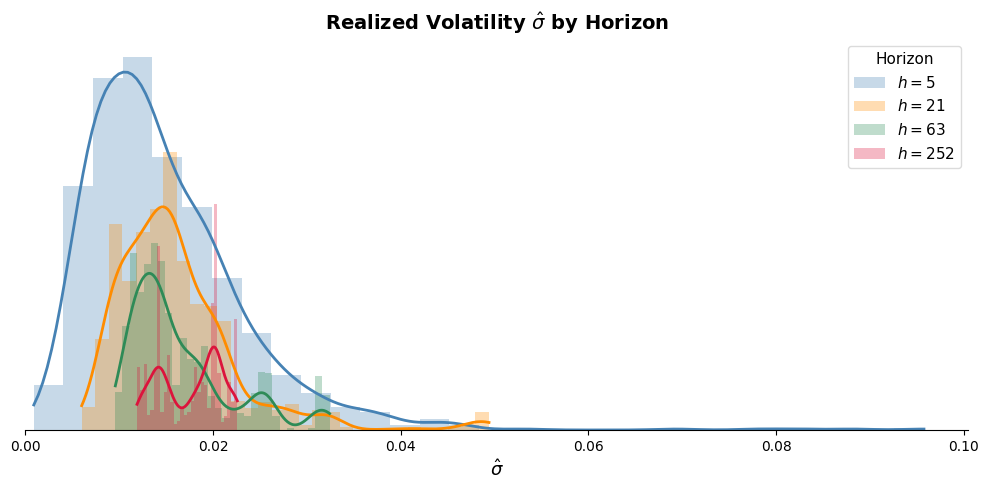

In [30]:
h_values = [5, 21, 63, 252]
colors = ["steelblue", "darkorange", "seagreen", "crimson"]

fig, ax = plt.subplots(figsize=(10, 5))

for h, color in zip(h_values, colors):
    df[f"RV_{h}"] = df["Log Returns"].rolling(window=h).std()
    sns.histplot(
        data=df[f"RV_{h}"].dropna(),
        kde=True,
        bins=30,
        ax=ax,
        label=f"$h = {h}$",
        color=color,
        alpha=0.3,
        line_kws={"linewidth": 2},
        edgecolor="none",
    )

ax.set_xlim(left=0)
ax.set_xlabel(r"$\hat{\sigma}$", fontsize=13)
ax.set_ylabel("")
ax.yaxis.set_visible(False)
ax.spines["left"].set_visible(False)
ax.set_title(r"Realized Volatility $\hat{\sigma}$ by Horizon", fontsize=14, fontweight="bold")
ax.legend(title="Horizon", fontsize=11, title_fontsize=11, framealpha=0.7)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Simple Moving Averages (SMA) & the Momentum Surface $\mu(W, t)$

#### 1. Simple Moving Average

For a price series $P_t$, the **Simple Moving Average** over a window of $W$ periods is:

$$\text{SMA}_W(t) = \frac{1}{W} \sum_{i=0}^{W-1} P_{t-i}$$

The code computes this for four horizons:

$$W \in \{5,\ 21,\ 63,\ 252\} \quad \text{(approx. 1 week, 1 month, 1 quarter, 1 year)}$$

Longer windows produce smoother estimates that suppress short-term noise, at the cost of increased **lag** — the SMA reacts more slowly to recent price changes. Formally, the lag of an SMA is:

$$\text{lag}(W) = \frac{W - 1}{2} \quad \text{periods}$$

---

#### 2. The Momentum Surface $\mu(W, t)$

The 3D surface generalises the SMA into a **continuous field** over both window size $W$ and time $t$, and defines a normalised momentum measure:

$$\mu(W,\, t) = -\frac{1}{\text{SMA}}\left[\frac{\partial\, \text{SMA}}{\partial W} + \frac{\partial\, \text{SMA}}{\partial t}\right]$$

Each partial derivative captures a distinct effect:

**Rate of change with respect to window size** $W$:

$$\frac{\partial\, \text{SMA}}{\partial W} \approx \frac{\text{SMA}_{W+\Delta W}(t) - \text{SMA}_{W-\Delta W}(t)}{2\,\Delta W}$$

This measures how sensitive the average is to the choice of smoothing horizon — i.e., how much the signal changes as we zoom out.

**Rate of change with respect to time** $t$:

$$\frac{\partial\, \text{SMA}}{\partial t} \approx \frac{\text{SMA}_W(t+1) - \text{SMA}_W(t-1)}{2}$$

This is the temporal momentum of the moving average — positive when the trend is rising, negative when falling.

**Normalisation** by $\text{SMA}$ makes $\mu$ scale-invariant (analogous to a log-derivative):

$$\mu(W,t) \approx -\frac{d}{d\,\cdot}\ln\bigl(\text{SMA}(W,t)\bigr)$$

so that $\mu$ can be compared across assets and time periods regardless of price level.

---

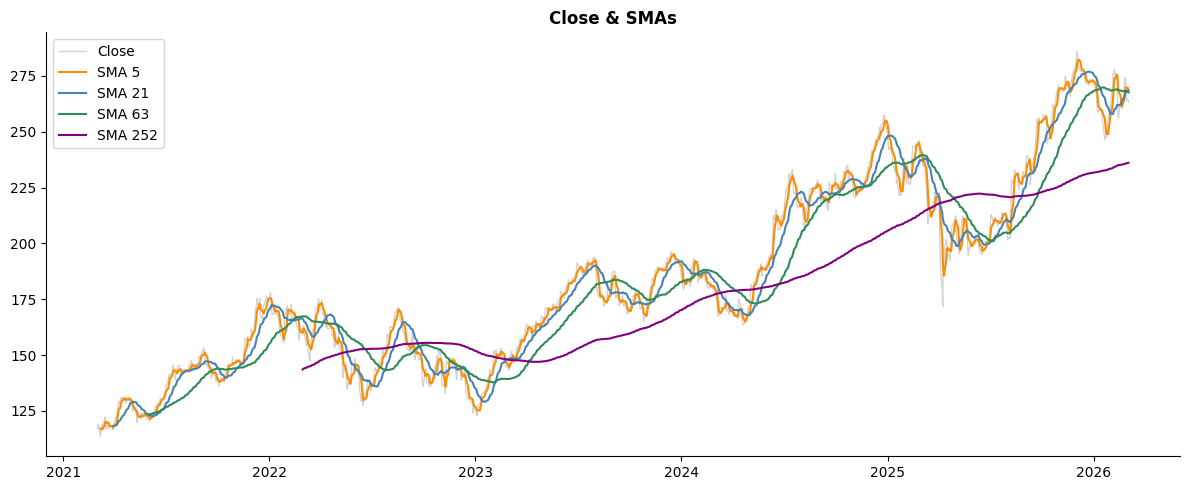

In [31]:
window_arr = [5, 21, 63, 252]
colors = ["darkorange", "steelblue", "seagreen", "purple"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["Close"], color="lightgrey", linewidth=1, label="Close", zorder=1)

for W, color in zip(window_arr, colors):
    ax.plot(df.index, df["Close"].rolling(W).mean(), color=color, linewidth=1.5, label=f"SMA {W}")

ax.set_title("Close & SMAs", fontweight="bold")
ax.set_xlabel("")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

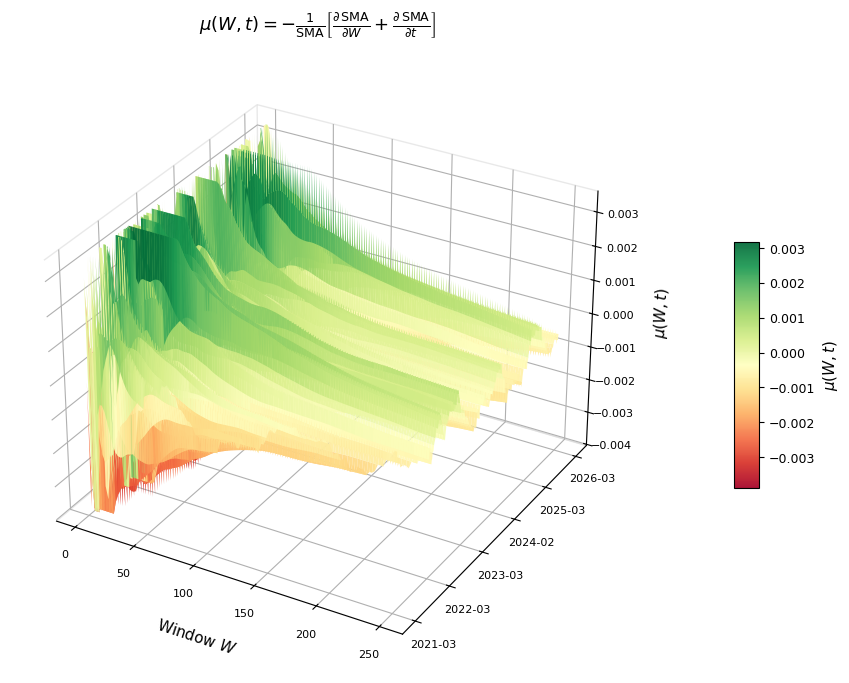

In [32]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

# Downsample for smoother rendering
step_w, step_t = 2, 3
W_ds = inner_windows[::step_w]
t_ds = np.arange(len(df))[::step_t]
mu_ds = mu[::step_t, ::step_w]
mu_ds = np.clip(mu_ds, np.nanpercentile(mu_ds, 1), np.nanpercentile(mu_ds, 99))

W_grid, t_grid = np.meshgrid(W_ds, t_ds)

surf = ax.plot_surface(
    W_grid, t_grid, mu_ds,
    cmap="RdYlGn",
    alpha=0.92,
    linewidth=0,
    antialiased=True,
    rcount=200,
    ccount=200,
)

# Colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.4, aspect=10, pad=0.1)
cbar.set_label(r"$\mu(W, t)$", fontsize=11)
cbar.ax.tick_params(labelsize=9)

# Date ticks on time axis
n = len(df)
tick_idx = np.linspace(0, n - 1, 6, dtype=int)
tick_labels = [df.index[i].strftime("%Y-%m") for i in tick_idx]
ax.set_yticks(tick_idx)
ax.set_yticklabels(tick_labels, fontsize=8)

ax.set_xlabel("Window $W$", fontsize=11, labelpad=10)
ax.set_ylabel("", fontsize=11, labelpad=30)
ax.set_zlabel(r"$\mu(W, t)$", fontsize=11, labelpad=10)
ax.set_title(
    r"$\mu(W,t) = -\frac{1}{\mathrm{SMA}}\left[\frac{\partial\,\mathrm{SMA}}{\partial W} + \frac{\partial\,\mathrm{SMA}}{\partial t}\right]$",
    fontsize=13, pad=20
)

ax.view_init(elev=30, azim=-60)
ax.tick_params(axis="both", labelsize=8)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("lightgrey")
ax.yaxis.pane.set_edgecolor("lightgrey")
ax.zaxis.pane.set_edgecolor("lightgrey")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

plt.show()

### Spearman Correlation Between $\mu(W, t)$ and Forward Realized Volatility $\hat{\sigma}(t+h)$

#### 1. Forward Realized Volatility

For each forecast horizon $h$, the **forward realized volatility** is the rolling standard deviation of log returns computed $h$ steps ahead:

$$\hat{\sigma}_h(t) = \sqrt{\frac{1}{h-1}\sum_{i=0}^{h-1}\left(r_{t+i} - \bar{r}_{t,h}\right)^2}$$

This is a **forward-looking** quantity — at time $t$, it summarises the volatility that will be *realised* over the next $h$ periods, making it a natural target for forecasting.

---

#### 2. Spearman Rank Correlation

For each pair $(W, h)$, the code computes the **Spearman rank correlation** between the momentum signal $\mu(W, t)$ and the forward volatility $\hat{\sigma}_h(t)$:

$$\rho_S(W, h) = 1 - \frac{6\sum_t d_t^2}{n(n^2 - 1)}, \quad d_t = \text{rank}\!\left(\mu(W,t)\right) - \text{rank}\!\left(\hat{\sigma}_h(t)\right)$$

Spearman's $\rho$ is preferred over Pearson's here for two reasons:

- **Robustness** — financial returns and volatility are heavy-tailed; rank-based measures are insensitive to outliers
- **Monotonic sensitivity** — it captures any monotonic relationship between $\mu$ and $\hat{\sigma}$, not just linear ones

A minimum sample guard of $n \geq 30$ overlapping observations is enforced before computing $\rho_S$ to avoid spurious correlations from small samples.

---

#### 3. The Correlation Matrix

The result is a matrix $\mathbf{R} \in \mathbb{R}^{|W| \times |h|}$ where each entry is:

$$\mathbf{R}_{i,j} = \rho_S\!\left(\mu(W_i,\, \cdot\,),\ \hat{\sigma}_{h_j}(\,\cdot\,)\right), \quad W_i \in [2, 252],\quad h_j \in [1, 125]$$

The axes therefore span:

| Axis | Variable | Range | Interpretation |
|---|---|---|---|
| $x$ | Forecast horizon $h$ | $1 \to 125$ | How far ahead we predict volatility |
| $y$ | SMA window $W$ | $2 \to 252$ | How long a trend signal we use |

---

#### 4. Interpretation

A positive $\rho_S(W, h)$ indicates that **larger momentum $\mu$ today predicts larger realised volatility $h$ steps ahead**, for a trend signal built on window $W$. Regions of the heatmap where $\rho_S$ is high reveal which $(W, h)$ combinations carry the most predictive information:

- **High $\rho_S$ at small $h$** — short-horizon momentum predicts near-term volatility spikes
- **High $\rho_S$ at large $W$**  — longer-term trend signals are more persistent predictors
- **Diagonal structure** (if present) — suggests a natural alignment between the trend window and the forecast horizon, i.e. $W \sim h$

The colormap is bounded at $\rho_S \in [0, 0.5]$, reflecting the expectation that predictability is positive but modest — consistent with weak-form market efficiency.

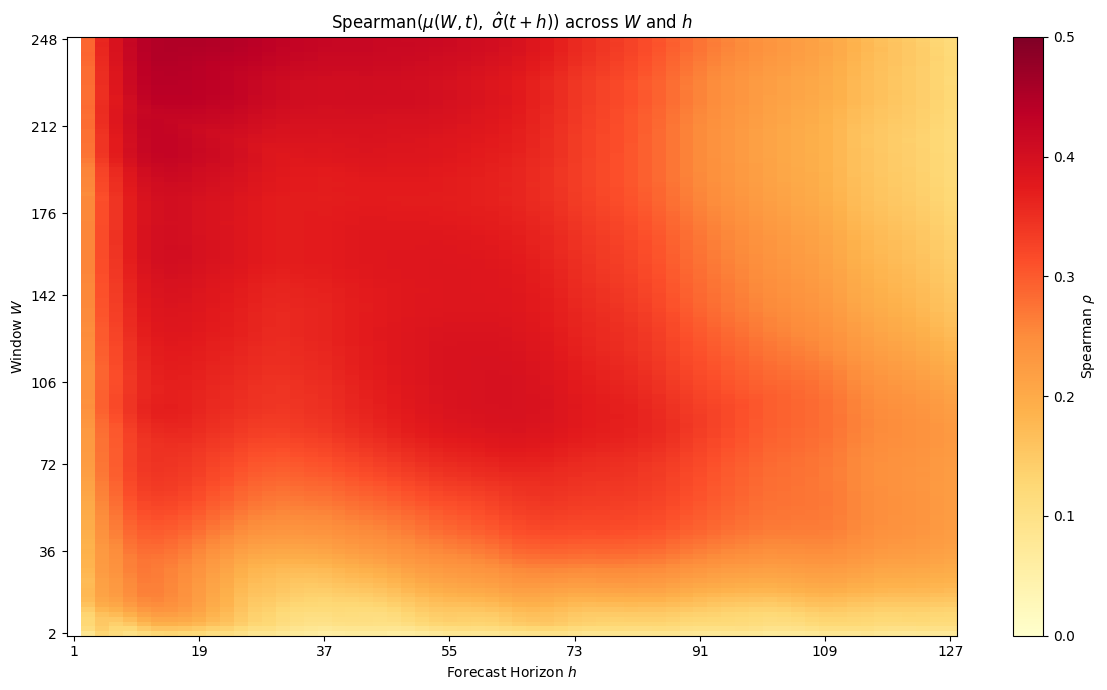

In [33]:
W_values = np.arange(2, max(inner_windows), 2)
h_values = np.arange(1, 126+2, 2)

# Forward RV surface
rv_surface = pd.concat(
    {h: df["Log Returns"].shift(-h).rolling(h).std() for h in h_values},
    axis=1
)
rv_surface.columns = h_values

# mu surface — already computed as mu (numpy array, rows=t, cols=W)
# rebuild as DataFrame for alignment
mu_surface = pd.DataFrame(mu, index=df.index, columns=inner_windows)
mu_surface = mu_surface[W_values]  # coarsen to match W_values

# Correlation matrix: rows=W, cols=h
corr_matrix = np.full((len(W_values), len(h_values)), np.nan)

for i, W in enumerate(W_values):
    for j, h in enumerate(h_values):
        x = mu_surface[W]
        y = rv_surface[h]
        mask = x.notna() & y.notna()
        if mask.sum() > 30:  # minimum sample guard
            corr_matrix[i, j], _ = spearmanr(x[mask], y[mask])

# Plot as heatmap
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(corr_matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.5, origin="lower")
fig.colorbar(im, ax=ax, label=r"Spearman $\rho$")

ax.set_xticks(np.linspace(0, len(h_values)-1, 8, dtype=int))
ax.set_xticklabels(h_values[np.linspace(0, len(h_values)-1, 8, dtype=int)])
ax.set_yticks(np.linspace(0, len(W_values)-1, 8, dtype=int))
ax.set_yticklabels(W_values[np.linspace(0, len(W_values)-1, 8, dtype=int)])

ax.set_xlabel("Forecast Horizon $h$")
ax.set_ylabel("Window $W$")
ax.set_title(r"Spearman$(\mu(W,t),\ \hat{\sigma}(t+h))$ across $W$ and $h$")
plt.tight_layout()
plt.show()

### Optimal $(W^*, h^*)$ Selection

The optimal pair is found by maximising the Spearman correlation over the full grid:

$$(W^*, h^*) = \underset{W,\, h}{\arg\max}\ \rho_S\!\left(\mu(W, t),\ \hat{\sigma}_h(t)\right)$$

located via `np.nanargmax` on the correlation matrix $\mathbf{R}$, which identifies the index of the globally highest $\rho_S$ while ignoring any $(W, h)$ pairs that failed the minimum sample guard ($n < 30$).

The resulting $W^*$ and $h^*$ define the **most predictive configuration** — the trend-window and forecast-horizon combination for which today's momentum signal has the strongest monotonic relationship with future realised volatility.

In [34]:
# Find optimal (W, h) pair
best_idx = np.unravel_index(np.nanargmax(corr_matrix), corr_matrix.shape)
best_W = W_values[best_idx[0]]
best_h = h_values[best_idx[1]]
best_rho = corr_matrix[best_idx]

print(f"Optimal Window:  W = {best_W} days")
print(f"Optimal Horizon: h = {best_h} days")
print(f"Spearman ρ:      {best_rho:.4f}")

Optimal Window:  W = 248 days
Optimal Horizon: h = 15 days
Spearman ρ:      0.4490
